# PACE Hackweek 2024
## Comparison of PACE and BGC-Argo backscatter @ 700nm
### Region: North Atlantic
Ellen Park\
\
\
Match-up code (authors: James Allen and Anna Windle) modified from PACE Hackweek [tutorial](https://pacehackweek.github.io/pace-2024/presentations/hackweek/satellite_insitu_matchups.html) 

Install [argopy](https://argopy.readthedocs.io/en/latest/) (Python library for accessing Argo float data)\
Note: this can take a little bit, and code is still in development 

In [1]:
%pip install argopy

  Using cached argopy-0.1.15-py3-none-any.whl.metadata (4.8 kB)
  Using cached erddapy-2.2.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached fsspec-2023.10.0-py3-none-any.whl.metadata (6.8 kB)
Using cached argopy-0.1.15-py3-none-any.whl (276 kB)
Using cached erddapy-2.2.0-py3-none-any.whl (22 kB)
Using cached fsspec-2023.10.0-py3-none-any.whl (166 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.6.1
    Uninstalling fsspec-2024.6.1:
      Successfully uninstalled fsspec-2024.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2024.6.1 requires fsspec==2024.6.1.*, but you have fsspec 2023.10.0 which is incompatible.
satpy 0.50.0 requires trollimage>=1.24, but you have trollimage 1.23.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import argopy
import numpy as np
import pandas as pd

In [3]:
argopy.set_options(src='erddap', mode='expert');

In [4]:
from argopy import DataFetcher  # This is the class to work with Argo data
from argopy import ArgoIndex  #  This is the class to work with Argo index

In [5]:
def GetFloatsWithArgopy(good_idx, target_parameters):
    float_values = np.zeros((good_idx.shape[0], len(target_parameters)))*np.NaN
    for fi in np.arange(float_values.shape[0]):
    # for fi in np.arange(157, float_values.shape[0]):
        fname = good_idx.loc[:,'file'].values[fi]
        
        wmo = int(fname.split('/')[1])
        profnum = int(fname.split('_')[-1].split('.')[0][:3])
    
        print(wmo, profnum)
        
        float_data = DataFetcher(ds='bgc', src = 'gdac').profile(wmo, profnum).load().data.to_dataframe()
        # Get surface data
        float_data = float_data.loc[float_data.loc[:,'PRES']<=10,:]
        
        
        # QC
        for ti in np.arange(len(target_parameters)):
            float_data.loc[(float_data.loc[:,target_parameters[ti]+'_ADJUSTED_QC']!=1) & \
            (float_data.loc[:,target_parameters[ti]+'_ADJUSTED_QC']!=2), target_parameters[ti]+'_ADJUSTED']=np.NaN
        
            float_values[fi, ti] = float_data.loc[:,target_parameters[ti]+'_ADJUSTED'].mean()

    return float_values


In [8]:
read_in = False

if read_in == True:
    # Get float data with argo py
    idx = ArgoIndex(index_file='bgc-s').load().to_dataframe()

    target_parameters = ['BBP700']
    good_inds = []
    
    for pi in np.arange(idx.shape[0]):
    
        param_count = 0
        for ti in np.arange(len(target_parameters)):
            
            if target_parameters[ti] in idx.loc[:, 'parameters'].values[pi].split(' '):
                param_count = param_count +1
    
        if param_count == len(target_parameters):
            good_inds.append(pi)
    
    good_idx = idx.iloc[good_inds,:]

    # Crop to target time period and region
    good_idx = good_idx.loc[good_idx.loc[:,'date']>pd.Timestamp(2024,7,19), :]

    # latN = 50; latS = 20; lonW = -80; lonE = -45
    
    # good_idx = good_idx.loc[(good_idx.loc[:,'latitude']<=latN) & (good_idx.loc[:,'latitude']>=latS) & \
    # (good_idx.loc[:,'longitude']<=lonE) & (good_idx.loc[:,'longitude']>=lonW), :]

    # Get float values with argopy
    float_values = GetFloatsWithArgopy(good_idx, target_parameters)

    # Temporarily save data because it takes awhile to get this
    # Append to index file
    for pi in np.arange(len(target_parameters)):
        good_idx = good_idx.assign(**{target_parameters[pi]+'_FLOAT': float_values[:,pi]})
    good_idx.to_pickle('float_data.pkl')
    
else:
    # read in previous values
    good_idx  = pd.read_pickle('float_data.pkl')

In [8]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [9]:
# Satellite Matchup Constants
# Short names for earthaccess lookup
SAT_LOOKUP = {
    "PACE": "PACE_OCI_L2_IOP_NRT",
    "AQUA": "MODISA_L2_OC",
    "TERRA": "MODIST_L2_OC",
    "NOAA-20": "VIIRSJ1_L2_OC",
    "NOAA-21": "VIIRSJ2_L2_OC",
    "SUOMI-NPP": "VIIRSN_L2_OC"
    }

# List l2 flags, then build them into a dict
l2_flags_list = [
    "ATMFAIL", "LAND", "PRODWARN", "HIGLINT", "HILT", "HISATZEN", "COASTZ",
    "SPARE", "STRAYLIGHT", "CLDICE", "COCCOLITH", "TURBIDW", "HISOLZEN",
    "SPARE", "LOWLW", "CHLFAIL", "NAVWARN", "ABSAER", "SPARE", "MAXAERITER",
    "MODGLINT", "CHLWARN", "ATMWARN", "SPARE", "SEAICE", "NAVFAIL", "FILTER",
    "SPARE", "BOWTIEDEL", "HIPOL", "PRODFAIL", "SPARE"]
L2_FLAGS = {flag: 1 << idx for idx, flag in enumerate(l2_flags_list)}

# Bailey and Werdell 2006 exclusion criteria
EXCLUSION_FLAGS = ["LAND", "HIGLINT", "HILT", "STRAYLIGHT", "CLDICE",
                   "ATMFAIL", "LOWLW", "FILTER", "NAVFAIL", "NAVWARN"]

# L2 Mask default
EXCLUSION_FLAGS = ["LAND", "HILT", "STRAYLIGHT", "CLDICE"]


sat = 'PACE'

In [17]:
def get_fivebyfive(file, latitude, longitude,):
    """
    Get stats on a 5x5 box around station coordinates of a satellite granule.

    Parameters
    ----------
    file : earthaccess granule object
        Satellite granule from earthaccess.
    latitude : float
        In decimal degrees for Aeronet-OC site for matchups
    longitude : float
        In decimal degrees (negative West) for Aeronet-OC site for matchups
    rrs_wavelengths ; numpy array
        Rrs wavelengths (from wavelength_3d for OCI)

    Returns
    -------
    None.
    """
    with xr.open_dataset(file, group="navigation_data") as ds_nav:
        sat_lat = ds_nav['latitude'].values
        sat_lon = ds_nav['longitude'].values

    # Calculate the Euclidean distance for 2D lat/lon arrays
    distances = np.sqrt((sat_lat - latitude)**2 + (sat_lon - longitude)**2)

    # Find the index of the minimum distance
    # Dimensions are (lines, pixels)
    min_dist_idx = np.unravel_index(np.argmin(distances), distances.shape)
    center_line, center_pixel = min_dist_idx

    # Get indices for a 5x5 box around the center pixel
    line_start = max(center_line - 2, 0)
    line_end = min(center_line + 2 + 1, sat_lat.shape[0])
    pixel_start = max(center_pixel - 2, 0)
    pixel_end = min(center_pixel + 2 + 1, sat_lat.shape[1])

    # Extract the data
    with xr.open_dataset(file, group="geophysical_data") as ds_data:
        #rrs_data = ds_data['Rrs'].isel(
        #    number_of_lines=slice(line_start, line_end),
        #    pixels_per_line=slice(pixel_start, pixel_end)
        #    ).values
        
        bbp_442 = ds_data['bbp_442'].isel(
            number_of_lines=slice(line_start, line_end),
            pixels_per_line=slice(pixel_start, pixel_end)
            ).values
        bbp_s = ds_data['bbp_s'].isel(
            number_of_lines=slice(line_start, line_end),
            pixels_per_line=slice(pixel_start, pixel_end)
            ).values
        
        bbp_data  = bbp_442*(700/442)**(-1*bbp_s)

        
        flags_data = ds_data['l2_flags'].isel(
            number_of_lines=slice(line_start, line_end),
            pixels_per_line=slice(pixel_start, pixel_end)
            ).values

    # Calculate the bitwise OR of all flags in EXCLUSION_FLAGS to get a mask
    exclude_mask = sum(L2_FLAGS[flag] for flag in EXCLUSION_FLAGS)

    # Create a boolean mask
    # True means the flag value does not contain any of the EXCLUSION_FLAGS
    valid_mask = np.bitwise_and(flags_data, exclude_mask) == 0

    bbp_std = np.nan
    bbp_mean = np.nan

    # Get stats and averages
    if valid_mask.any():
        bbp_valid = bbp_data[valid_mask]
        bbp_std_initial = np.nanstd(bbp_valid, axis=0)
        bbp_mean_initial = np.nanmean(bbp_valid, axis=0)

    bbp_mean_raw = np.nanmean(bbp_data)
    bbp_std_raw = np.nanstd(bbp_data)
    # Get unmasked values
    

    # Put in dictionary of the row
    row = {
        "oci_datetime": pd.to_datetime(file.granule["umm"]["TemporalExtent"]
                                       ["RangeDateTime"]["BeginningDateTime"]),
        "oci_latitude": sat_lat[center_line, center_pixel],
        "oci_longitude": sat_lon[center_line, center_pixel],
        "oci_pixel_valid": np.sum(valid_mask),
        "oci_bbp_mean_qc": bbp_mean,
        "oci_bbp_std_qc": bbp_std,
        "oci_bbp_mean_raw": bbp_mean_raw,
        "oci_bbp_std_raw": bbp_std_raw,
    }


    return row


def process_satellite(start_date, end_date, latitude, longitude, sat="PACE",
                      selected_dates=None):
    """
    Download and process satellite data for matchups.

    Caution: If the date or coordinates aren't formatted correctly, it might
    pull a huge granule list and take forever to run. If it takes more than 45
    seconds to print the number of granules, just kill the process.

    Uses the earthaccess package. Defaults to the PACE OCI L2 IOP datasets,
    but other satellites can be used if they have a corresponding short_name
    in the SAT_LOOKUP dictionary.

    Workflow:
        1. Get list of matchup granules
        2. Loop through each file and:
            2a. Find closest pixel to station, extract 5x5 pixel box
            2b. Exclude pixels based on l2_flags
            2c. Filtered mean to get single spectra
            2d. Compute statistics and save data row
        3. Organize output pandas dataframe

    Parameters
    ----------
    start_date : datetime or str
        Beginning of Aeronet data to run.
    end_date : datetime or str, optional
        End of Aeronet data to run.
    latitude : float
        In decimal degrees for Aeronet-OC site for matchups
    longitude : float
        In decimal degrees (negative West) for Aeronet-OC site for matchups
    sat : str
        Name of satellite to search. Must be in SAT_LOOKUP dict constant.
    selected_dates : list of str, optional
        If given, only pull granules if the dates are in this list

    Returns
    -------
    pandas DataFrame object
        Flattened table of all satellite granule matchups.

    """
    # Look up short name from constants
    if sat not in SAT_LOOKUP.keys():
        raise ValueError(f"{sat} is not in the lookup dictionary. Available "
                         f"sats are: {', '.join(SAT_LOOKUP)}")
    short_name = SAT_LOOKUP[sat]

    # Format search parameters
    #time_bounds = (f"{start_date}T00:00:00", f"{end_date}T23:59:59")
    time_bounds = (start_date, end_date)

    # Run Earthaccess data search
    results = earthaccess.search_data(point=(longitude, latitude),
                                      temporal=time_bounds,
                                      short_name=short_name)
    if selected_dates is not None:
        filtered_results = [
            result for result in results
            if result["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:10]
            in selected_dates
            ]
        print(f"Filtered to {len(filtered_results)} Granules.")
        files = earthaccess.open(filtered_results)
    else:
        files = earthaccess.open(results)


    # Loop through files and process
    sat_rows = []
    for idx, file in enumerate(files):
        granule_date = pd.to_datetime(file.granule["umm"]["TemporalExtent"]
                                      ["RangeDateTime"]["BeginningDateTime"])
        print(f"Running Granule: {granule_date}")
        row = get_fivebyfive(file, latitude, longitude,)
        sat_rows.append(row)

    return pd.DataFrame(sat_rows)

In [ ]:
rerun = False
if rerun:
    sat_values = np.zeros((good_idx.shape[0],2))*np.NaN
    
    # Append satellite values
    good_idx = good_idx.assign(BBP700_SAT = sat_values[:,0])
    good_idx = good_idx.assign(BBP700_SAT_RAW = sat_values[:,1])
    float_inds = np.arange(good_idx.shape[0])
else:
    good_idx = pd.read_pickle('floatsat_data.pkl')
    
    sat_values = good_idx.loc[:,['BBP700_SAT', 'BBP700_SAT_RAW']].values
    last_idx = np.where(np.isnan(sat_values[:,1])==False)[0][-1]
    float_inds = np.arange(last_idx, good_idx.shape[0])
          
# Only get float matchups where there are bbp700 datat
hour_window  = 12
for fi in np.arange(float_inds.shape[0]):
#for i in np.arange(24,good_idx.shape[0]+1) :
    i = float_inds[fi]
    print('index',i)
    start_date  = str(good_idx.loc[:,'date'].values[i]-np.timedelta64(hour_window,'h'))
    end_date = str(good_idx.loc[:,'date'].values[i]+np.timedelta64(hour_window,'h'))
    longitude = good_idx.loc[:,'longitude'].values[i]
    latitude = good_idx.loc[:,'latitude'].values[i]
    selected_dates = [str(good_idx.loc[:,'date'].values[i])]
    ii = good_idx.index.values[i]
    
    bbp_value = good_idx.loc[:,'BBP700_SAT_RAW'].values[i]
    
    if np.isnan(longitude) == False and np.isnan(latitude) == False and np.isnan(bbp_value)==False:
        sat_cb = process_satellite(start_date=start_date, end_date=end_date,
                          latitude=latitude, longitude=longitude, sat="PACE",)
                          #selected_dates=selected_dates)
    
        sat_values[i,0] = sat_cb.loc[:,'oci_bbp_mean_qc'].mean()
        sat_values[i,1] = sat_cb.loc[:,'oci_bbp_mean_raw'].mean()
        print(sat_cb.loc[:,'oci_bbp_mean_qc'].mean(), sat_cb.loc[:,'oci_bbp_mean_raw'].mean())

    good_idx.loc[ii, 'BBP700_SAT'] = sat_cb.loc[:,'oci_bbp_mean_qc'].mean()
    good_idx.loc[ii, 'BBP700_SAT_RAW'] = sat_cb.loc[:,'oci_bbp_mean_raw'].mean()

    # Save outputs
    good_idx.to_pickle('floatsat_data.pkl')

index 0
2024-07-19T21:32:57


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

Running Granule: 2024-07-19 12:01:35+00:00
Running Granule: 2024-07-19 13:34:54+00:00
nan 0.0009200707
index 1
2024-07-29T20:44:49


...

Running Granule: 2024-08-03 22:13:28+00:00
nan 0.0017306373
index 99
2024-07-19T10:24:44


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Running Granule: 2024-07-19 01:51:45+00:00


In [32]:
import cartopy.crs as ccrs

/srv/conda/envs/notebook/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_82/1052800338.py:34: RuntimeWarning: invalid value encountered in log10
  vmin = np.nanmin(np.log10(good_idx.loc[:,['BBP700_FLOAT','BBP700_SAT_RAW']].values))
/tmp/ipykernel_82/1052800338.py:35: RuntimeWarning: invalid value encountered in log10
  vmax = np.nanmax(np.log10(good_idx.loc[:,['BBP700_FLOAT','BBP700_SAT_RAW']].values))


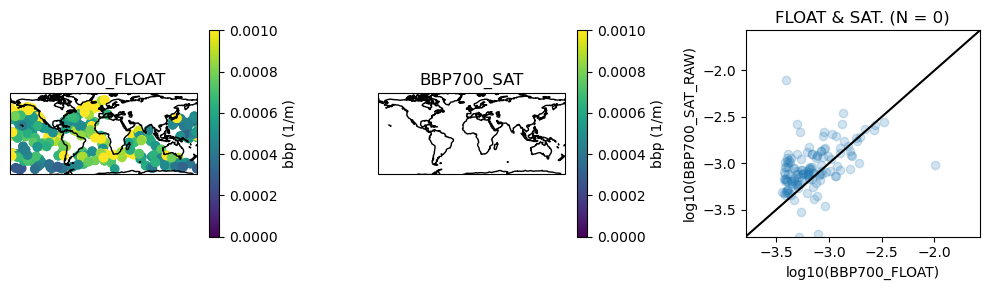

In [36]:
fig = plt.figure(figsize = (10,3))
r = 1; c = 3
params = ['BBP700_FLOAT','BBP700_SAT_RAW']

for fi in np.arange(len(params)):

    ax = fig.add_subplot(r,c,int(fi+1), projection=ccrs.PlateCarree())
    
    cs = ax.scatter(good_idx.loc[:,'longitude'], good_idx.loc[:,'latitude'],c = good_idx.loc[:,params[fi]], vmin = 0, vmax = 1e-3)

    # Circle floats that have a match up
    matchup_inds = np.where((np.isnan(good_idx.loc[:,'BBP700_FLOAT'].values)==False) & \
                            (np.isnan(good_idx.loc[:,'BBP700_SAT_RAW'].values)==False) )[0]

    ax.scatter(good_idx.loc[:,'longitude'].values[matchup_inds], good_idx.loc[:,'latitude'].values[matchup_inds],\
              facecolors = 'None', edgecolors = 'r')
    
    ax.set_xlabel('Longitude')
    # ax.set_xlim([lonW, lonE])
    # ax.set_ylim([latS, latN])
    if fi == 0:
        ax.set_ylabel('Latitude')
    else: 
        ax.set_yticklabels([])
    fig.colorbar(cs, ax = ax, label = 'bbp (1/m)')

    ax.set_title(params[fi])
    ax.coastlines()

ax = fig.add_subplot(r,c, int(fi+2))
ax.scatter(np.log10(good_idx.loc[:,'BBP700_FLOAT']), np.log10(good_idx.loc[:,'BBP700_SAT_RAW']), alpha = 0.2)
#vmin = 0
#vmax = 1e-3
vmin = np.nanmin(np.log10(good_idx.loc[:,['BBP700_FLOAT','BBP700_SAT_RAW']].values))
vmax = np.nanmax(np.log10(good_idx.loc[:,['BBP700_FLOAT','BBP700_SAT_RAW']].values))
ax.set_xlim([vmin, vmax])
ax.set_ylim([vmin, vmax])
ax.plot([vmin,vmax], [vmin,vmax],'k-')
ax.set_ylabel('log10(BBP700_SAT_RAW)')
ax.set_xlabel('log10(BBP700_FLOAT)')
ts = 'FLOAT & SAT. (N = '+str(int(matchup_inds.shape[0]))+')'
ax.set_title(ts)
fig.tight_layout()

In [18]:
matchup_inds.shape

(15,)

In [69]:
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 757MB
Dimensions:        (number_of_bands: 286, number_of_reflective_bands: 286,
                    wavelength_3d: 19, number_of_lines: 1710,
                    pixels_per_line: 1272)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 152B 351.0 361.0 ... 678.0 711.0
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/37)
    wavelength     (number_of_bands) float64 2kB ...
    vcal_gain      (number_of_reflective_bands) float32 1kB ...
    vcal_offset    (number_of_reflective_bands) float32 1kB ...
    F0             (number_of_reflective_bands) float32 1kB ...
    aw             (number_of_reflective_bands) float32 1kB ...
    bbw            (number_of_reflective_bands) float32 1kB ...
    ...             ...
    adg_unc_442    (number_of_lines, pixels_per_line) float32 9MB ...
    bbp_unc_442    (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags       (number_of_lines, pixels_per_line) int32 9MB ...
    longitude      (number_of_lines, pixels_per_line) float32 9MB ...
    latitude       (number_of_lines, pixels_per_line) float32 9MB ...
    tilt           (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data IOP
    product_name:                      PACE_OCI.20240701T175112.L2.OC_IOP.V2_...
    processing_version:                2.0
    history:                           l2gen par=/data8/sdpsoper/vdc/vpu7/wor...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -63.887604
    geospatial_lon_min:                -99.13216
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9674437642097473

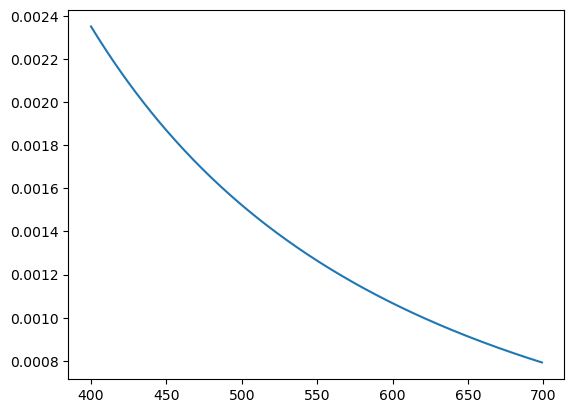

In [76]:
plt.plot(np.arange(400,700),dataset.bbp_442.values[0,6]*(np.arange(400,700)/442)**(-1*dataset.bbp_s.values[0,6]))

In [74]:
np.where(np.isnan(dataset.bbp_442.values)==False)

(array([   0,    0,    0, ..., 1709, 1709, 1709]),
 array([   6,    7,    8, ..., 1222, 1223, 1225]))